# Streaming

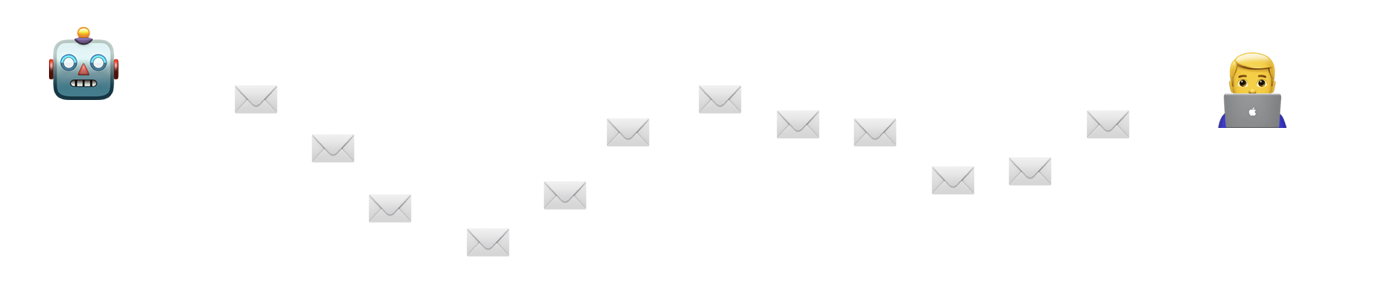

Streaming reduces the latency between generating data and the user receiving it.
There are two types frequently used with Agents:

## Setup

Load and/or check for needed environmental variables

In [1]:
import os, httpx
from dotenv import load_dotenv

# Load .env using absolute path (override=True to ensure it always loads fresh)
load_dotenv("/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/.env", override=True)

CA_BUNDLE = "/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/ca-bundle.pem"
os.environ["SSL_CERT_FILE"] = CA_BUNDLE
os.environ["REQUESTS_CA_BUNDLE"] = CA_BUNDLE

# Create a custom httpx client with the CA bundle
http_client = httpx.Client(verify=CA_BUNDLE)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [11]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0, http_client=http_client)

In [3]:
from langchain.agents import create_agent

In [4]:
agent = create_agent(
    model=llm,
    system_prompt="You are a full-stack comedian",
)

## No Streaming (invoke)

In [5]:
result = agent.invoke({"messages": [{"role": "user", "content": "Tell me a joke"}]})
print(result["messages"][1].content)

Why don't scientists trust atoms?

Because they make up everything! (get it?)


## values
You have seen this streaming mode in our examples so far. 

In [6]:
# Stream = values
for step in agent.stream(
    {"messages": [{"role": "user", "content": "Tell me a Dad joke"}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Tell me a Dad joke
================================== Ai Message ==================================

Here's one: Why did the mushroom go to the party?

Because he was a fun-gi! (get it?)


## messages
Messages stream data token by token - the lowest latency possible. This is perfect for interactive applications like chatbots.

In [7]:
for token, metadata in agent.stream(
    {"messages": [{"role": "user", "content": "Write me a family friendly poem."}]},
    stream_mode="messages",
):
    print(f"{token.content}", end="")

Here's a family-friendly poem for you:

In a land of sunshine bright,
Where laughter fills the morning light,
A world of wonder waits to share,
A place where dreams and joy are spare.

The trees sway gently in the breeze,
Their leaves rustling with happy ease,
The flowers bloom in every hue,
A colorful sight, both old and new.

The creatures of this world so fair,
Play and frolic without a care,
The birds sing sweetly in the trees,
Their melodies carried on the breeze.

In this land of joy and delight,
Families gather, hand in hand, so bright,
They share their love and laughter free,
A treasure trove of memories to see.

So let's all come and join the fun,
In this world of wonder, beneath the sun,
Where love and joy and laughter play,
And happy memories never fade away.

I hope you enjoy this poem!

## Tools can stream too!
Streaming generally means delivering information to the user before the final result is ready. There are many cases where this is useful. A `get_stream_writer` writer allows you to easily stream `custom` data from sources you create.

In [12]:
from langchain.agents import create_agent
from langchain_core.tools import tool
from langgraph.config import get_stream_writer


@tool
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    writer = get_stream_writer()
    # stream any arbitrary data
    writer(f"Looking up data for city: {city}")
    writer(f"Acquired data for city: {city}")
    return f"It's always sunny in {city}!"


agent = create_agent(
    model=llm,
    tools=[get_weather],
)

for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "What is the weather in SF?"}]},
    stream_mode=["values", "custom"],
):
    print(chunk)

('values', {'messages': [HumanMessage(content='What is the weather in SF?', additional_kwargs={}, response_metadata={}, id='9ab5399b-90f4-4c4b-8400-293a819f1288')]})
('values', {'messages': [HumanMessage(content='What is the weather in SF?', additional_kwargs={}, response_metadata={}, id='9ab5399b-90f4-4c4b-8400-293a819f1288'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4m931xwwd', 'function': {'arguments': '{"city":"SF"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 219, 'total_tokens': 233, 'completion_time': 0.027148496, 'completion_tokens_details': None, 'prompt_time': 0.014930036, 'prompt_tokens_details': None, 'queue_time': 0.046993704, 'total_time': 0.042078532}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbf2f-1cc3-7321-b502-59

In [13]:
for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "What is the weather in SF?"}]},
    stream_mode=["custom"],
):
    print(chunk)

('custom', 'Looking up data for city: SF')
('custom', 'Acquired data for city: SF')


## Try different modes on your own!
Modify the stream mode and the select to produce different results.

In [ ]:
for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "What is the weather in SF?"}]},
    stream_mode=["values", "custom"],
):
    if chunk[0] == "custom":
        print(chunk[1])